---
## Part 1 — Setup

Two imports. That's all the SDK needs.

- `arc_agi` — the client library. Entry point is `arc_agi.Arcade()`.
- `arcengine` — the game engine types. You'll use `GameAction` and `GameState` from here.


1. Create the connection -> read in API key and instantiate object to communicate with Server ARC-AGI Prize API

In [ ]:
import arc_agi
from arcengine import GameAction
import numpy as np

# arc = arc_agi.Arcade() 

from arc_agi.base import OperationMode

arc = arc_agi.Arcade(operation_mode=OperationMode.ONLINE) # ONLINE or COMPETITION mode

""" 
<- This line instantiates an object from the Arcade class, which belongs to the arc_agi module. 
Create the client. Reads ARC_API_KEY from .env if present. 

ARC-AGI (Abstraction and Reasoning Corpus for Artificial General Intelligence) is a benchmark created by 
François Chollet to measure general fluid intelligence in AI systems.

arc_agi is a client/SDK wrapper around the ARC-AGI Prize API. 

arc_agi — the module (likely imported earlier via import arc_agi)
Arcade — a class defined inside that module

So arc is now an instance of Arcade, giving you access to whatever methods and attributes that class exposes 
(e.g. arc.load_task(...), arc.submit(...), etc.).


"""
 
print("Client created:", arc)

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-04-24 12:16:45 | INFO | Successfully fetched 25 environment(s) from API
Client created: <arc_agi.base.Arcade object at 0x1067f57f0>


In [2]:
card_id = arc.create_scorecard(tags=["notebook-01"])
print(f"https://arcprize.org/scorecards/{card_id}")

2026-04-24 12:16:55 | INFO | Created new scorecard: 2b3b6654-c1e3-429f-a14a-5b8f047400d4
https://arcprize.org/scorecards/2b3b6654-c1e3-429f-a14a-5b8f047400d4


---
## Part 2 — The Environment Object (`env`)

`arc.make("ls20")` loads a game and returns an environment.
The environment is your handle to the game — you'll use it for the entire episode.

1. Download the environment from the Server

In [3]:
env = arc.make("ls20", scorecard_id=card_id)

# env.info holds static metadata about the game — it never changes during a run
info = env.info
print("game_id :", info.game_id)
print("title   :", info.title)
print("tags    :", info.tags)

2026-04-24 12:18:01 | INFO | Successfully fetched metadata for game ls20
2026-04-24 12:18:01 | INFO | Successfully reset game ls20-9607627b, guid=18ee2459-aad2-4797-a525-09bd9ee31a6a, scorecard_id=2b3b6654-c1e3-429f-a14a-5b8f047400d4
game_id : ls20-9607627b
title   : LS20
tags    : ['keyboard']


## Don't create same env on the same scorecard:

make() just creates a new env object — it doesn't reset or invalidate previous ones. Calling it twice with the same card_id gives you two independent game runs both reporting to the same scorecard. Their actions and levels stack:


scorecard.total_actions = run1_actions + run2_actions
scorecard.total_levels_completed = run1_levels + run2_levels
Since your score is measured as action efficiency, every redundant run burns your budget. If you want a clean restart, create a new scorecard — don't reuse the same card_id across multiple make() calls.

In [4]:
# The action space: all actions this game supports
print("action_space:", env.action_space)
print()
print("action names:", [a.name for a in env.action_space])
print("action ids  :", [a.value for a in env.action_space])

action_space: [<GameAction.ACTION1: 1>, <GameAction.ACTION2: 2>, <GameAction.ACTION3: 3>, <GameAction.ACTION4: 4>]

action names: ['ACTION1', 'ACTION2', 'ACTION3', 'ACTION4']
action ids  : [1, 2, 3, 4]


**Observe:** `env.action_space` gives you `GameAction` objects. For ls20 you get ACTION1–ACTION4.
These map to: **up, down, left, right**.

> **Question:** Is `env.action_space` the same as `obs.available_actions`? 
> You'll find out in Part 3. Keep this question in mind.

---
## Part 3 — The Observation Object (`obs`)

Every interaction with the game returns an **observation** (`FrameDataRaw`).
It contains everything you know about the current game state.

`env.reset()` starts a new episode and returns the first observation.

1. Start the session/game
2. the game ends after you complete n-levels withoug losing the 3 available lives

In [5]:
obs = env.reset()

print("=== Observation fields ===")
print("state            :", obs.state)
print("levels_completed :", obs.levels_completed)
print("win_levels       :", obs.win_levels)
print("available_actions:", obs.available_actions)
print("full_reset       :", obs.full_reset)
print("guid             :", obs.guid)
print("obs frame        :", obs.frame[0][0])

2026-04-24 12:18:41 | INFO | Successfully reset game ls20-9607627b, guid=18ee2459-aad2-4797-a525-09bd9ee31a6a, scorecard_id=2b3b6654-c1e3-429f-a14a-5b8f047400d4
=== Observation fields ===
state            : GameState.NOT_FINISHED
levels_completed : 0
win_levels       : 7
available_actions: [1, 2, 3, 4]
full_reset       : False
guid             : 18ee2459-aad2-4797-a525-09bd9ee31a6a
obs frame        : [5 5 5 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]


In [6]:
# The frame: the visual state of the game
frame = obs.frame[0]   # index 0 = the primary frame layer

print("frame type  :", type(frame))
print("frame shape :", frame.shape)    # always (64, 64)
print("frame dtype :", frame.dtype)    # int8
print("color values:", np.unique(frame).tolist())  # which color indices appear

frame type  : <class 'numpy.ndarray'>
frame shape : (64, 64)
frame dtype : int8
color values: [0, 1, 3, 4, 5, 8, 9, 11, 12]


In [8]:
print(obs.frame)

[array([[5, 5, 5, ..., 4, 4, 4],
       [5, 5, 5, ..., 4, 4, 4],
       [5, 5, 5, ..., 4, 4, 4],
       ...,
       [4, 5, 5, ..., 5, 8, 8],
       [4, 5, 5, ..., 5, 8, 8],
       [4, 4, 4, ..., 5, 5, 5]], shape=(64, 64), dtype=int8)]


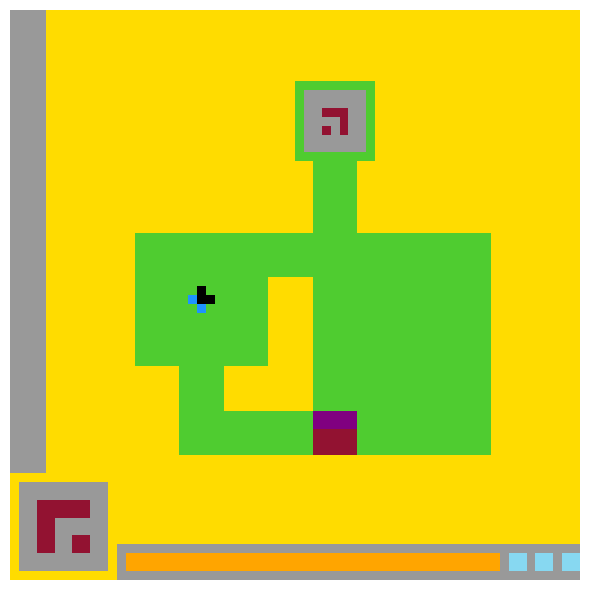

In [7]:
import sys
sys.path.insert(0, '.') 
from utils import render_frame

render_frame(frame)

# Part 4 - Understanding actions: mapping - (The RHML Gym paradigm). 

1. why action space is found in env and not in obs? 

env class -> arc_agi.local_wrapper.LocalEnvironmentWrapper

obs class -> arcengine.enums.FrameDataRaw

This is the OpenAI Gym paradigm, and ARC-AGI SDK follows it deliberately.

In Gym:

```
env = gym.make("CartPole-v1")   # the MDP
obs = env.reset()               # the current state
The separation reflects a fundamental distinction in RL:
```



|  | env | obs |
| :--- | :--- | :--- |
| **What it is** | The MDP — the game itself | A snapshot — one moment in time |
| **Lifetime** | Entire session | One step |
| **ARC class** | `LocalEnvironmentWrapper` | `FrameDataRaw` |
| **Owns** | `action_space`, `info`, `reset()`, `step()` | `frame`, `state`, `available_actions` |

In [10]:
# UNDERSTANDING ACTIONS
# Answer: is env.action_space the same as obs.available_actions?
# Compare them below.

space_ids = [a.value for a in env.action_space]
available  = obs.available_actions

print("env.action_space ids  :", space_ids)
print("obs.available_actions :", available)

env.action_space ids  : [1, 2, 3, 4]
obs.available_actions : [1, 2, 3, 4]


**Key distinction:**
- `env.action_space` — all actions the game *ever* supports (static, set at game load)
- `obs.available_actions` — actions legal *right now* in the current state (can change step to step)

Always filter your action selection to `obs.available_actions`. Sending an illegal action wastes your budget.

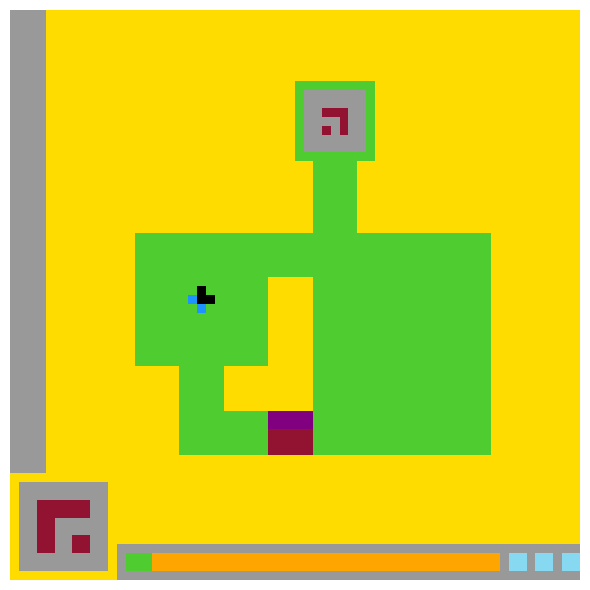

In [10]:
# Send ACTION1 (move up)
obs = env.step(GameAction.ACTION3)
frame_after = obs.frame[0]

render_frame(frame_after)

---
## Part 4 — Taking Actions

`env.step(action)` sends one action and returns the next observation.
The only input is a `GameAction` enum value.

2026-04-24 09:00:37 | INFO | Successfully reset game ls20-9607627b, guid=ff272c22-b2c8-4b9d-9d80-5391418251e3, scorecard_id=ac2d80b7-db60-49e0-84d4-5b213d886329
ACTION3: state=NOT_FINISHED, pixels_changed=52


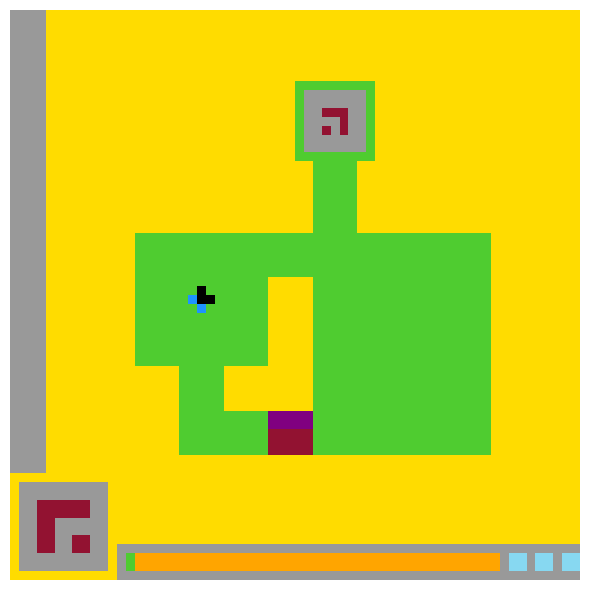

ACTION3: state=NOT_FINISHED, pixels_changed=52


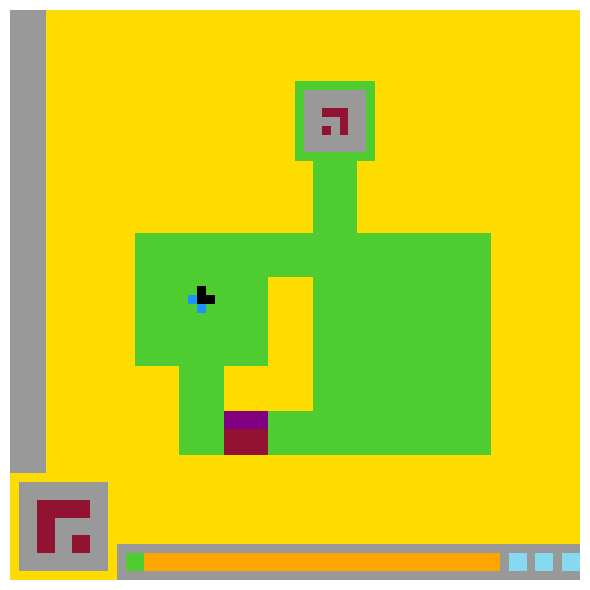

ACTION3: state=NOT_FINISHED, pixels_changed=52


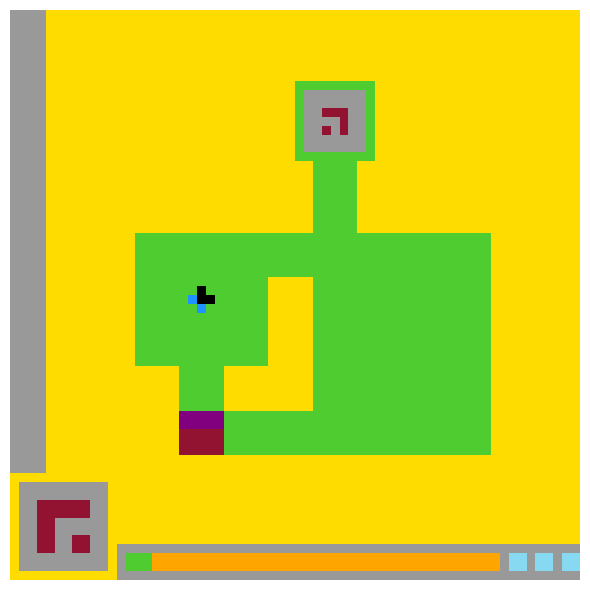

ACTION1: state=NOT_FINISHED, pixels_changed=52


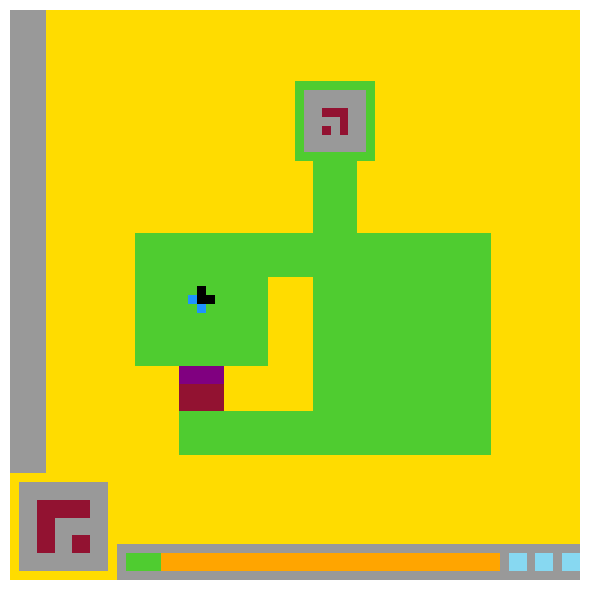

ACTION1: state=NOT_FINISHED, pixels_changed=52


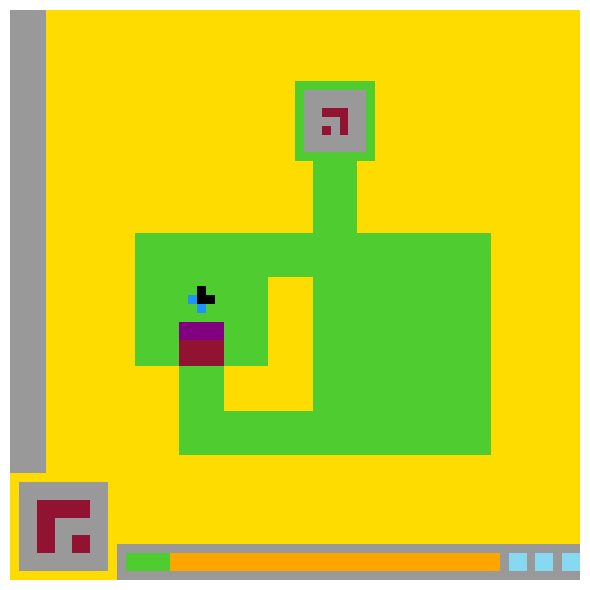

ACTION1: state=NOT_FINISHED, pixels_changed=118


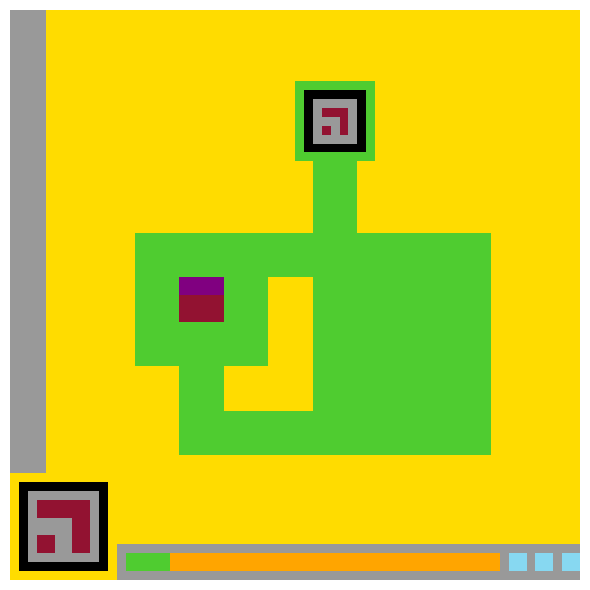

ACTION1: state=NOT_FINISHED, pixels_changed=112


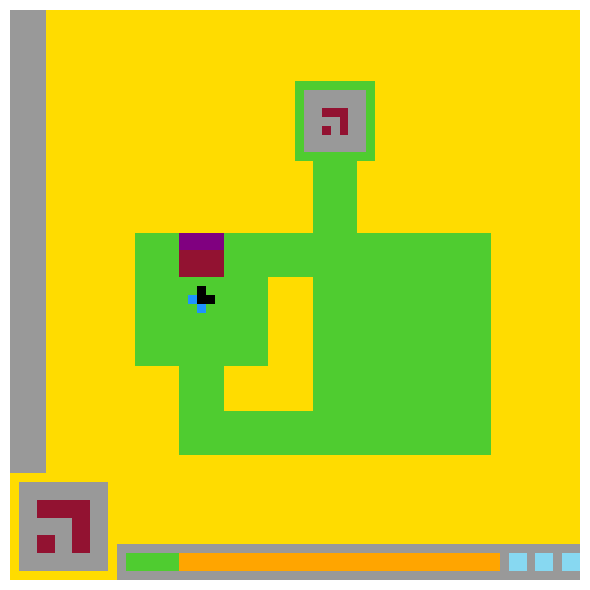

ACTION4: state=NOT_FINISHED, pixels_changed=52


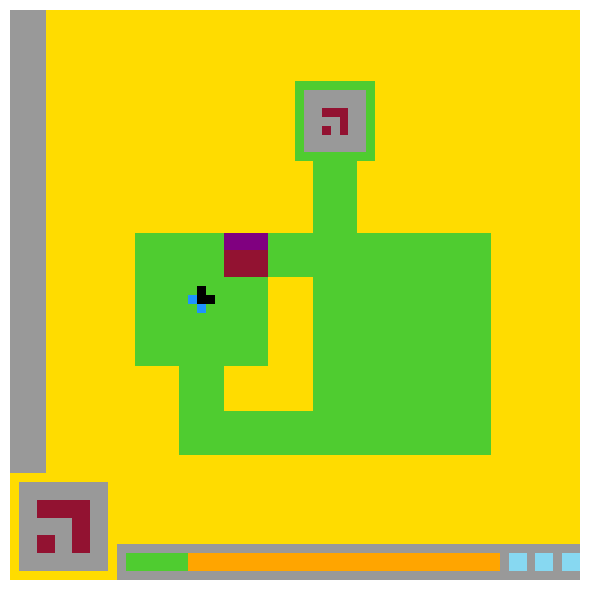

ACTION4: state=NOT_FINISHED, pixels_changed=52


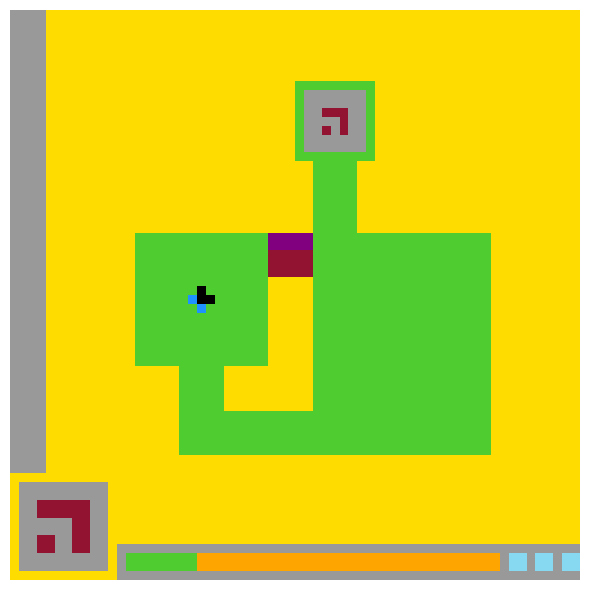

ACTION4: state=NOT_FINISHED, pixels_changed=52


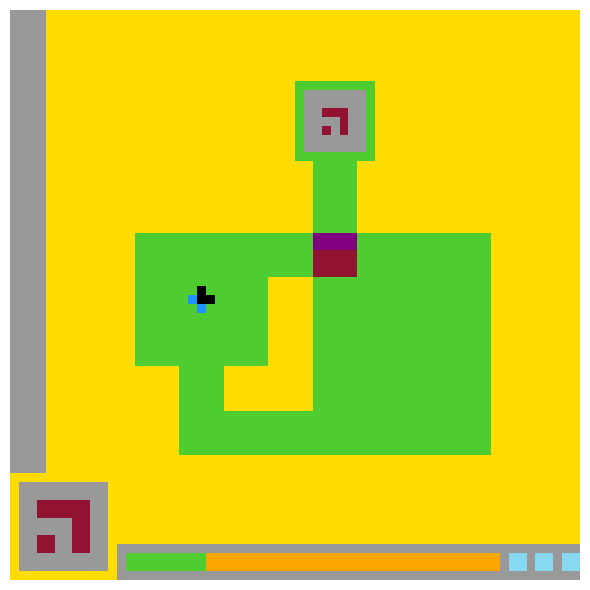

ACTION1: state=NOT_FINISHED, pixels_changed=52


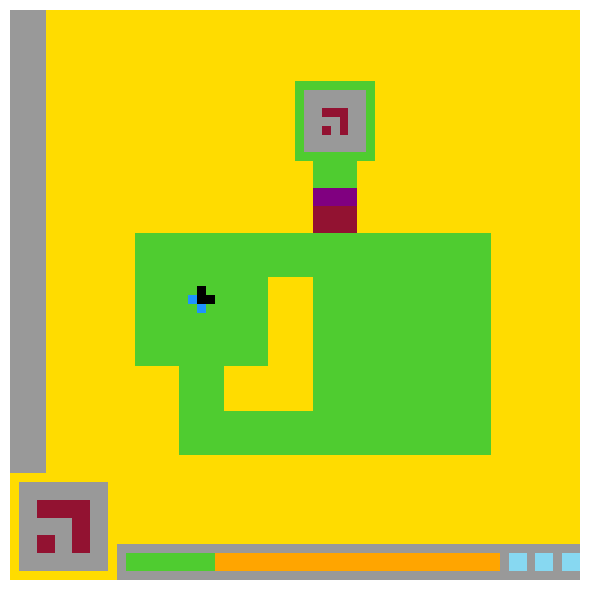

ACTION1: state=NOT_FINISHED, pixels_changed=52


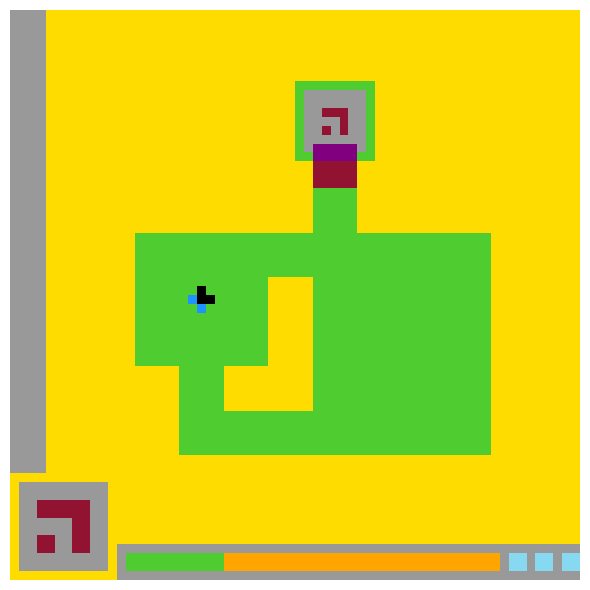

ACTION1: state=NOT_FINISHED, pixels_changed=49
  *** LEVEL COMPLETE — levels_completed=1, win_levels=7 ***


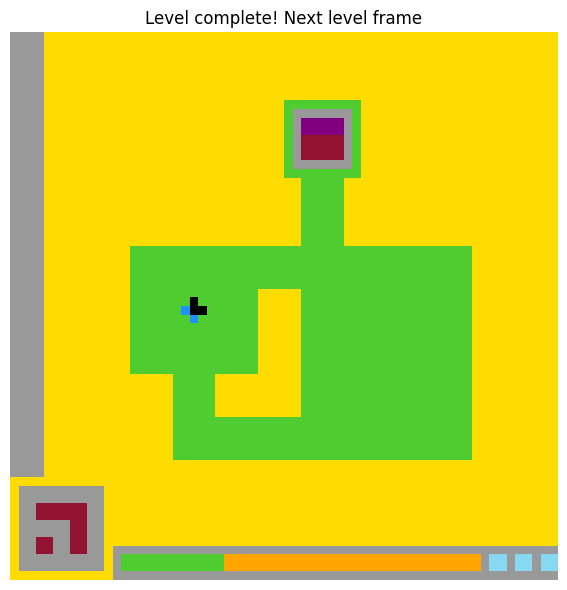

In [15]:
# YOUR TURN
# Send ACTION3 (move left) and check: how many pixels changed this time?
# Then send ACTION2 (move down) and ACTION4 (move right).
# After each step, print obs.state and the number of changed pixels.
obs = env.reset()

for action in [GameAction.ACTION3, GameAction.ACTION3, GameAction.ACTION3, 
               GameAction.ACTION1,GameAction.ACTION1, GameAction.ACTION1,GameAction.ACTION1,
               GameAction.ACTION4,GameAction.ACTION4,GameAction.ACTION4,
               GameAction.ACTION1,GameAction.ACTION1,GameAction.ACTION1]:
    prev_frame = obs.frame[0].copy()
    obs = env.step(action)
    changed = np.sum(prev_frame != obs.frame[0])
    print(f"{action.name}: state={obs.state.name}, pixels_changed={changed}")

    if obs.state.name == "WIN" or obs.levels_completed > 0:
        print(f"  *** LEVEL COMPLETE — levels_completed={obs.levels_completed}, win_levels={obs.win_levels} ***")
        render_frame(obs.frame[0], title=f"Level complete! Next level frame")
    else:
        render_frame(obs.frame[0])


2026-04-24 09:00:54 | INFO | Successfully reset game ls20-9607627b, guid=ff272c22-b2c8-4b9d-9d80-5391418251e3, scorecard_id=ac2d80b7-db60-49e0-84d4-5b213d886329


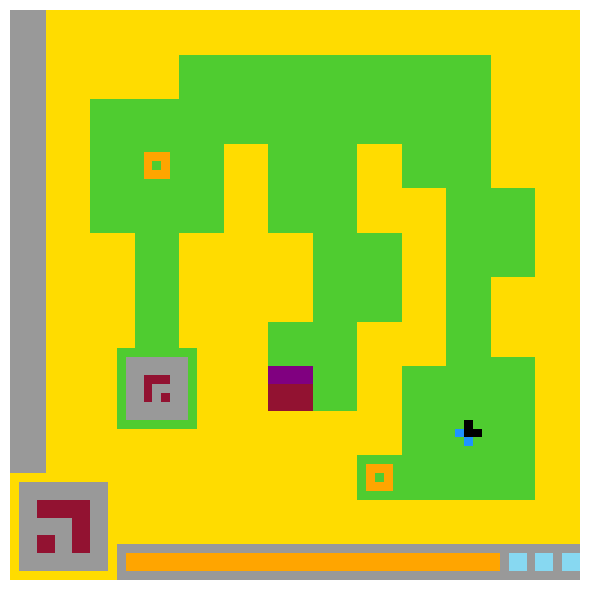

In [16]:
obs = env.step(GameAction.ACTION1)
obs = env.reset()
render_frame(obs.frame[0])

---
## Part 5 — Game End States

The game ends when `obs.state` is no longer `NOT_FINISHED`.

| State | Meaning |
|-------|---------|
| `NOT_FINISHED` | Game in progress — keep stepping |
| `WIN` | All levels completed (`levels_completed == win_levels`) |
| `GAME_OVER` | Failed — reset and try again |


So the three signals are:

1. obs.levels_completed increases → one level done, next level loaded in obs.frame[0]
2. obs.state == WIN → all 7 levels done, game over (you won)
3. obs.state == GAME_OVER → ran out of actions/lives

In [17]:
scorecard = arc.close_scorecard(card_id)
print("score:", scorecard.score)
print(f"View at: https://arcprize.org/scorecards/{scorecard.card_id}")

2026-04-24 09:00:59 | INFO | Closed scorecard: ac2d80b7-db60-49e0-84d4-5b213d886329
score: 3.571428571428571
View at: https://arcprize.org/scorecards/ac2d80b7-db60-49e0-84d4-5b213d886329
